[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter7_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 7: Cointegration and VECM

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Common stochastic trends: the drunk and her dog; four real pairs.
- The Engle–Granger two-step method: why its critical values differ from Dickey–Fuller; Phillips–Ouliaris.
- Error correction models and half-lives.
- The Johansen tests, the term-structure VECM, impulse responses; VECM against a VAR in differences out of sample.
- Applications: purchasing power parity for EUR/RON, ROBOR and Euribor, three Central European currencies, pairs trading on the Bucharest Stock Exchange and on US banks.
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 9; Hamilton (1994), Ch. 19–20; Lütkepohl (2005), Ch. 6–8; Engle and Granger (1987); Johansen (1988, 1991).
- The first code cell installs the `arch` package if it is missing (`pip install arch`).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (Phillips-Ouliaris test) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `eg_test(y, x)`: Engle–Granger (OLS of $y$ on a constant and $x$, ADF on the residuals with MacKinnon p-values) and Phillips–Ouliaris $Z_t$; $H_0$: no cointegration.
- `ecm_fit(y, x)`: $\Delta y_t = c + \gamma\hat u_{t-1} + \delta_0\Delta x_t + \dots$; half-life $\ln 0.5/\ln(1 + \gamma)$.
- `johansen(df)`: trace and maximum-eigenvalue tests with an unrestricted constant and BIC lags.

In [6]:
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, acf
from statsmodels.tsa.adfvalues import mackinnoncrit, mackinnonp
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen, select_order
from statsmodels.tsa.api import VAR
from arch.unitroot.cointegration import phillips_ouliaris
SEED = 2026
YIELDS = ['GS1', 'GS5', 'GS10']
YIELD_START = '1960-01-01'
HICP_RO = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
HICP_EA = ('prc_hicp_minr', 'M.I15.TOTAL.EA')
ROBOR = ('irt_st_m', 'M.IRT_M3.RO')
EURIBOR = ('irt_st_m', 'M.IRT_M3.EA')
CONS_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.P31_S14.RO')
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
BVB = ['TLV.RO', 'BRD.RO', 'SNP.RO', 'TGN.RO', 'TEL.RO', 'EL.RO', 'SNG.RO', 'SNN.RO']
US_BANKS = ['JPM.US', 'BAC.US', 'C.US', 'WFC.US', 'GS.US', 'MS.US']
PAIR = ['TLV.RO', 'BRD.RO']
PAIR_START = '2014-01-01'
FORM, TRADE, ENTRY = 252, 126, 2.0
COST_BVB, COST_US = 0.002, 0.0005


def us_yields(cols=YIELDS, start=YIELD_START):
    """US Treasury constant-maturity yields (FRED, monthly averages, % per year), monthly PeriodIndex."""
    f = read_fred(cols).dropna().loc[start:]
    f.index = pd.PeriodIndex(f.index, freq='M')
    return f


def us_macro():
    """US quarterly real GDP, consumption and investment (statsmodels macrodata, 1959Q1-2009Q3), 100 ln."""
    d = load_statsmodels('macrodata')
    return 100 * np.log(d[['realgdp', 'realcons', 'realinv']]).rename(
        columns={'realgdp': 'y', 'realcons': 'c', 'realinv': 'i'})


def cee_fx(start='2005-07-01'):
    """EUR/RON, EUR/HUF and EUR/PLN (month-end, from the BNR reference rates: EUR/HUF = EUR/RON / HUF/RON), 100 ln."""
    e, h, p = (read_reference_rate(c, start=start) for c in ('EUR', 'HUF', 'PLN'))
    d = pd.concat([e, h, p], axis=1, keys=['eur', 'huf', 'pln']).dropna()
    fx = pd.DataFrame({'EUR/RON': d.eur, 'EUR/HUF': 100 * d.eur / d.huf, 'EUR/PLN': d.eur / d.pln})
    return 100 * np.log(fx.resample('ME').last())


def stock(symbol, start):
    """Adjusted close of a stock from data/market (weekdays)."""
    t = read_market(symbol)
    s = pd.to_numeric(t['adjusted_close'], errors='coerce').loc[start:'2026-09-18'].dropna()
    s = s[s > 0]
    return s[s.index.dayofweek < 5].rename(symbol.split('.')[0])


def stock_panel(symbols, start, calendar='bet'):
    """Several stocks on a common calendar (BET or S&P 500 trading days); a missing quote is carried forward
    for at most 5 days (no trade that day), then the rows with any missing value are dropped."""
    cal = load_close(calendar, start=start).index
    P = pd.concat([stock(s, start) for s in symbols], axis=1).reindex(cal).ffill(limit=5)
    return P.dropna()


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def ts_index(x):
    """A DatetimeIndex for plotting (PeriodIndex -> timestamps)."""
    return x.index.to_timestamp() if isinstance(x.index, pd.PeriodIndex) else x.index


def adf_test(x, reg='c'):
    """ADF test (lags by AIC): statistic, MacKinnon p-value, lags, 5% critical value."""
    r = adfuller(np.asarray(pd.Series(x).dropna(), float), regression=reg, autolag='AIC')
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'crit5': float(r[4]['5%'])}


def ols(y, X):
    """OLS with a constant: coefficients, standard errors, t-statistics, residuals, R^2, DW."""
    m = sm.OLS(np.asarray(y, float), sm.add_constant(np.asarray(X, float))).fit()
    e = m.resid
    return {'b': m.params.tolist(), 'se': m.bse.tolist(), 't': m.tvalues.tolist(), 'r2': float(m.rsquared),
            'dw': float(np.sum(np.diff(e) ** 2) / np.sum(e ** 2)), 'resid': e, 'n': int(m.nobs)}


def eg_test(y, x, trend='c'):
    """Engle-Granger two-step test: OLS of y on a constant and x (step 1), ADF on the residuals with lags by AIC
    and MacKinnon (2010) p-values for len(x)+1 variables (step 2); Phillips-Ouliaris Z_t on the same regression."""
    y = pd.Series(y)
    X = pd.DataFrame(x)
    d = pd.concat([y, X], axis=1).dropna()
    yv, Xv = d.iloc[:, 0], d.iloc[:, 1:]
    stat, p, cv = coint(yv, Xv, trend=trend, autolag='aic')
    step1 = ols(yv, Xv)
    po = phillips_ouliaris(yv, Xv, trend=trend, test_type='Zt')
    lags = adfuller(step1['resid'], regression='n', autolag='AIC')[2]
    return {'n': int(len(d)), 'beta': [float(b) for b in step1['b'][1:]], 'const': float(step1['b'][0]),
            'r2': step1['r2'], 'dw': step1['dw'], 'tau': float(stat), 'p': float(p), 'crit5': float(cv[1]),
            'crit1': float(cv[0]), 'crit10': float(cv[2]), 'lags': int(lags), 'po_zt': float(po.stat),
            'po_p': float(po.pvalue), 'po_crit5': float(po.critical_values[5]),
            'adf_crit5': float(mackinnoncrit(N=1, regression='c', nobs=len(d))[1])}


def half_life(rho):
    """Half-life (periods) of a deviation that decays like rho^h: ln(0.5)/ln(rho), for 0 < rho < 1."""
    return float(np.log(0.5) / np.log(rho)) if 0 < rho < 1 else float('inf')


def johansen(df, det_order=0, k_ar_diff=None, maxlags=8):
    """Johansen trace and maximum-eigenvalue tests (MacKinnon-Haug-Michelis critical values via statsmodels).
    k_ar_diff = lags of the differences in the VECM, by BIC on the levels VAR if None. The rank is the first r whose
    null is not rejected at 5% in the sequence r = 0, 1, ..."""
    x = df.dropna()
    if k_ar_diff is None:
        k_ar_diff = int(max(select_order(x, maxlags=maxlags, deterministic='co').bic, 1))
    r = coint_johansen(x, det_order, k_ar_diff)
    k = x.shape[1]
    rank = lambda s, c: next((i for i in range(k) if s[i] < c[i, 1]), k)
    return {'n': int(len(x)), 'k_ar_diff': k_ar_diff, 'eig': r.eig.tolist(), 'trace': r.lr1.tolist(),
            'trace_cv5': r.cvt[:, 1].tolist(), 'maxeig': r.lr2.tolist(), 'maxeig_cv5': r.cvm[:, 1].tolist(),
            'rank_trace': rank(r.lr1, r.cvt), 'rank_maxeig': rank(r.lr2, r.cvm), 'first': str(x.index[0])[:10],
            'last': str(x.index[-1])[:10]}


def ecm_fit(y, x, lags=1):
    """Single-equation ECM (two steps): e_t = y_t - a - b x_t from the levels regression, then
    Delta y_t = c + gamma e_{t-1} + delta_0 Delta x_t + sum_j (phi_j Delta y_{t-j} + delta_j Delta x_{t-j}) + eps_t."""
    d = pd.concat([pd.Series(y, name='y'), pd.Series(x, name='x')], axis=1).dropna()
    s1 = ols(d.y, d.x)
    e = pd.Series(s1['resid'], index=d.index)
    Z = pd.DataFrame({'e1': e.shift(1), 'dx': d.x.diff()})
    for j in range(1, lags + 1):
        Z[f'dy{j}'] = d.y.diff().shift(j)
        Z[f'dx{j}'] = d.x.diff().shift(j)
    Z['dy'] = d.y.diff()
    Z = Z.dropna()
    m = sm.OLS(Z.dy, sm.add_constant(Z.drop(columns='dy'))).fit()
    g = float(m.params['e1'])
    return {'beta': float(s1['b'][1]), 'a': float(s1['b'][0]), 'gamma': g, 'gamma_se': float(m.bse['e1']),
            'gamma_t': float(m.tvalues['e1']), 'delta0': float(m.params['dx']), 'delta0_se': float(m.bse['dx']),
            'const': float(m.params['const']), 'r2': float(m.rsquared), 'n': int(m.nobs), 'half': half_life(1 + g),
            'params': {k: float(v) for k, v in m.params.items()}, 'tvalues': {k: float(v) for k, v in m.tvalues.items()}}

## 1. Common stochastic trends

- The drunk and her dog (Murray 1994); four real pairs.

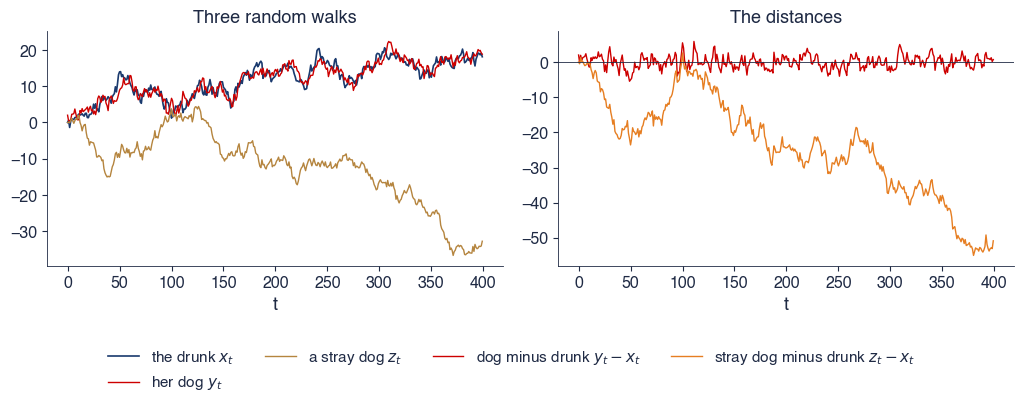

{'stat': -7.208212079655054, 'p': 2.2707206396685976e-10, 'lags': 4, 'crit5': -2.8688850015516016}


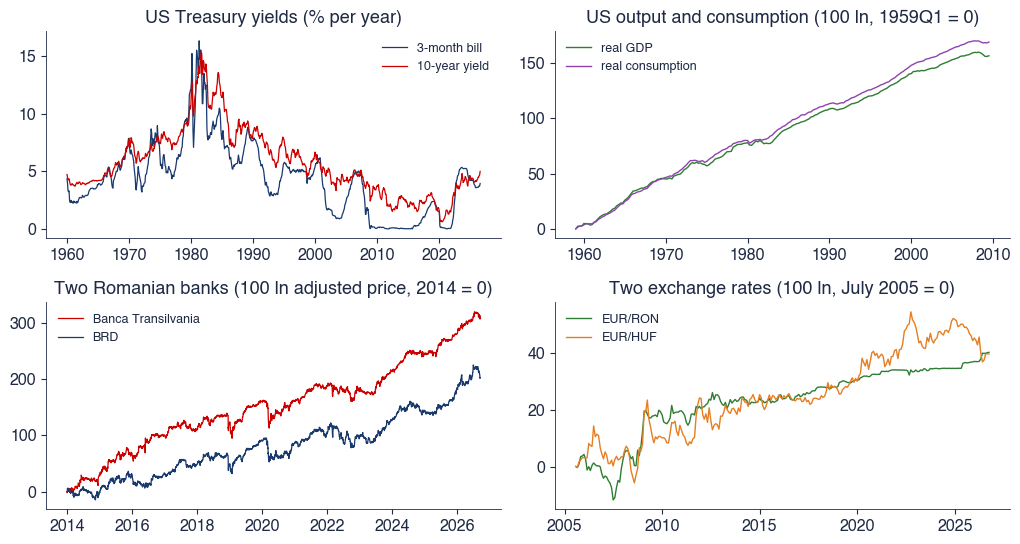

{'rates': (-3.35, 0.048),
 'cons': (-3.54, 0.029),
 'banks': (-4.33, 0.002),
 'fx': (-2.47, 0.294)}

In [7]:
def fig_drunk_dog(T=400, c=0.15, d=0.25, save_it=True):
    """Murray (1994): the drunk x_t and her dog y_t both wander (random walks), but each corrects part of the
    distance between them: x_t = x_{t-1} + u_t + c (y_{t-1} - x_{t-1}), y_t = y_{t-1} + w_t + d (x_{t-1} - y_{t-1}).
    A stray dog z_t is an independent random walk. The distance y - x is stationary (AR(1) with rho = 1 - c - d);
    the distance z - x wanders."""
    rng = np.random.default_rng(SEED)
    u, w, v = rng.standard_normal((3, T))
    x, y, z = np.zeros(T), np.zeros(T), np.zeros(T)
    y[0] = 2.0
    for t in range(1, T):
        x[t] = x[t - 1] + u[t] + c * (y[t - 1] - x[t - 1])
        y[t] = y[t - 1] + w[t] + d * (x[t - 1] - y[t - 1])
        z[t] = z[t - 1] + v[t]
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.4))
    ax[0].plot(x, color=st.MainBlue, lw=1.2, label='the drunk $x_t$')
    ax[0].plot(y, color=st.IDAred, lw=1.0, label='her dog $y_t$')
    ax[0].plot(z, color=st.Amber, lw=1.0, label='a stray dog $z_t$')
    ax[0].set_title('Three random walks')
    ax[0].set_xlabel('t')
    ax[1].plot(y - x, color=st.IDAred, lw=1.0, label='dog minus drunk $y_t - x_t$')
    ax[1].plot(z - x, color=st.Orange, lw=1.0, label='stray dog minus drunk $z_t - x_t$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('The distances')
    ax[1].set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=4, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_drunk_dog', save_it)
    return {'T': T, 'c': c, 'd': d, 'rho': 1 - c - d, 'half': half_life(1 - c - d),
            'adf_x': adf_test(x), 'adf_dist': adf_test(y - x), 'adf_stray': adf_test(z - x),
            'sd_dist': float(np.std(y - x)), 'sd_stray': float(np.std(z - x)), 'eg': eg_test(y, x)}


def fig_examples(save_it=True):
    """Four pairs of I(1) series: US 3-month bill and 10-year yields (FRED TB3MS, GS10); US real consumption and
    real GDP (macrodata); Banca Transilvania and BRD (adjusted prices, since 2014); EUR/RON and EUR/HUF."""
    out = {}
    f = read_fred(['TB3MS', 'GS10']).dropna().loc[YIELD_START:]
    m = us_macro()
    m.index = pd.period_range('1959Q1', periods=len(m), freq='Q').to_timestamp()
    P = 100 * np.log(stock_panel(PAIR, PAIR_START))
    fx = cee_fx()
    fx = fx - fx.iloc[0]
    fig, ax = plt.subplots(2, 2, figsize=(10.4, 5.6))
    a = ax[0, 0]
    a.plot(f.index, f.TB3MS, color=st.MainBlue, lw=0.9, label='3-month bill')
    a.plot(f.index, f.GS10, color=st.IDAred, lw=0.9, label='10-year yield')
    a.set_title('US Treasury yields (% per year)')
    years_axis(a, 10)
    a.legend(loc='upper right', fontsize=9)
    a = ax[0, 1]
    a.plot(m.index, m.y - m.y.iloc[0], color=st.Forest, lw=1.0, label='real GDP')
    a.plot(m.index, m.c - m.c.iloc[0], color=st.Purple, lw=1.0, label='real consumption')
    a.set_title('US output and consumption (100 ln, 1959Q1 = 0)')
    years_axis(a, 10)
    a.legend(loc='upper left', fontsize=9)
    a = ax[1, 0]
    a.plot(P.index, P.TLV - P.TLV.iloc[0], color=st.IDAred, lw=0.9, label='Banca Transilvania')
    a.plot(P.index, P.BRD - P.BRD.iloc[0], color=st.MainBlue, lw=0.9, label='BRD')
    a.set_title('Two Romanian banks (100 ln adjusted price, 2014 = 0)')
    years_axis(a, 2)
    a.legend(loc='upper left', fontsize=9)
    a = ax[1, 1]
    a.plot(fx.index, fx['EUR/RON'], color=st.Forest, lw=1.0, label='EUR/RON')
    a.plot(fx.index, fx['EUR/HUF'], color=st.Orange, lw=1.0, label='EUR/HUF')
    a.set_title('Two exchange rates (100 ln, July 2005 = 0)')
    years_axis(a, 5)
    a.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    save('tsa_ch7_examples', save_it)
    out['rates'] = eg_test(f.GS10, f.TB3MS)
    out['cons'] = eg_test(m.c, m.y)
    out['banks'] = eg_test(P.TLV, P.BRD)
    out['fx'] = eg_test(fx['EUR/RON'], fx['EUR/HUF'])
    for k, s in [('rates_tb3', f.TB3MS), ('rates_gs10', f.GS10), ('cons_c', m.c), ('cons_y', m.y),
                 ('tlv', P.TLV), ('brd', P.BRD)]:
        out['adf_' + k] = adf_test(s, 'ct' if k[:4] in ('cons', 'tlv', 'brd') else 'c')
    out['spread_mean'] = float((f.GS10 - f.TB3MS).mean())
    return out


print(fig_drunk_dog(save_it=False)['adf_dist'])
ex = fig_examples(save_it=False)
{k: (round(v['tau'], 2), round(v['p'], 3)) for k, v in ex.items() if isinstance(v, dict) and 'tau' in v}

## 2. The Engle–Granger method

- The null distribution by simulation; tests on real pairs; the step-1 residuals.

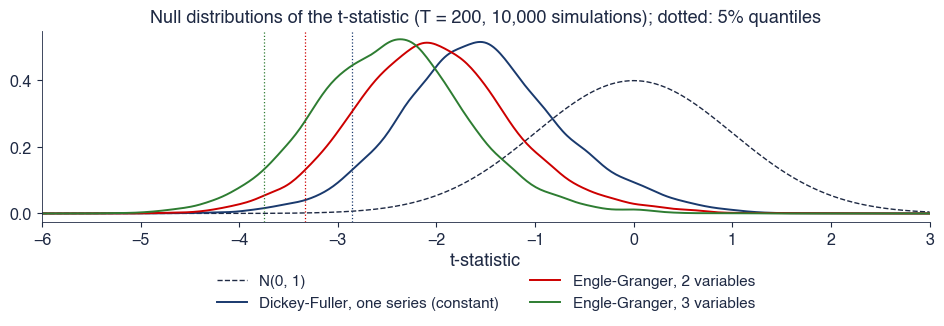

{1: {'q05': -2.8562760254899806, 'q01': -3.487406242444003, 'q10': -2.5618201034111387, 'mk5': -2.876102355, 'mk1': -3.463476079125, 'mk10': -2.574532225}, 2: {'q05': -3.33210779779878, 'q01': -3.9150311654931866, 'q10': -3.0506632802292413, 'mk5': -3.366851075, 'mk1': -3.952037675, 'mk10': -3.065724, 'size_with_df': 0.1455}, 3: {'q05': -3.753598044360437, 'q01': -4.313959527779512, 'q10': -3.4720223018533236, 'mk5': -3.78374380225, 'mk1': -4.366740945875, 'mk10': -3.4833444499999997, 'size_with_df': 0.303}}


,beta,tau,lags,p,PO Zt,PO p
US consumption on income,1.075,-3.535,0.0,0.029,-3.520,0.031
US 10-year on 3-month yield,0.856,-3.352,20.0,0.048,-4.042,0.006
TLV on BRD,1.359,-4.335,3.0,0.002,-4.143,0.005
EUR/RON on EUR/HUF,0.708,-2.467,0.0,0.294,-2.433,0.309
Romania consumption on GDP,1.462,-2.322,8.0,0.363,-6.801,0.000
"TLV on BRD, from 2010",1.675,-1.817,3.0,0.622,-1.825,0.619
"TLV on BRD, reversed",0.712,-4.163,3.0,0.004,-4.018,0.007
US income on consumption,0.930,-3.562,0.0,0.027,-3.549,0.029


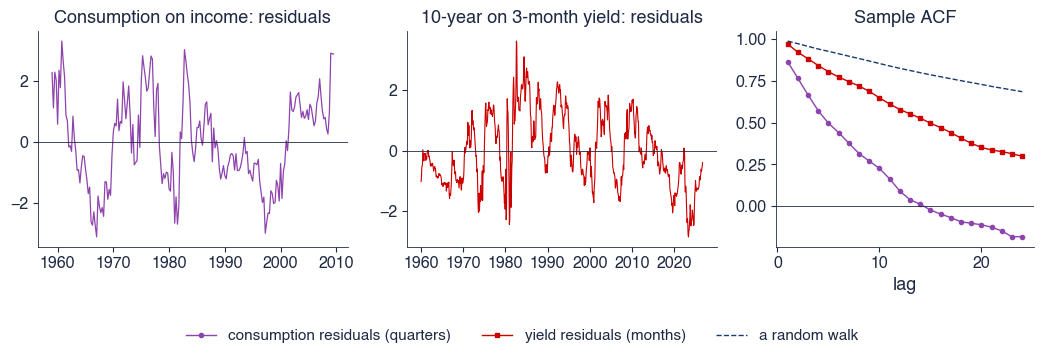

{'acf1_cons': 0.8622046942394398,
 'acf1_rates': 0.966977542808734,
 'acf12_rates': 0.5774568179458125,
 'acf8_cons': 0.3149176090644475,
 'sd_cons': 1.44607980538762,
 'sd_rates': 1.1608345294769553}

In [8]:
def eg_tau_batch(n_var, T, R, rng):
    """R values of the Dickey-Fuller t-statistic (no lags, no constant in the test regression) on the residuals of
    the OLS regression of one random walk on n_var - 1 other, independent random walks and a constant; n_var = 1:
    the Dickey-Fuller test with a constant on a single random walk."""
    out = np.empty(R)
    for r in range(R):
        W = rng.standard_normal((T, n_var)).cumsum(axis=0)
        if n_var == 1:
            e = W[:, 0] - W[:, 0].mean()
        else:
            X = np.column_stack([np.ones(T), W[:, 1:]])
            e = W[:, 0] - X @ np.linalg.lstsq(X, W[:, 0], rcond=None)[0]
        de, el = np.diff(e), e[:-1]
        g = (el @ de) / (el @ el)
        s2 = np.sum((de - g * el) ** 2) / (len(de) - 1)
        out[r] = g / np.sqrt(s2 / (el @ el))
    return out


def fig_eg_dist(T=200, R=10000, save_it=True):
    """Null distributions (no cointegration) of the residual-based Dickey-Fuller statistic for 2 and 3 variables,
    against the Dickey-Fuller distribution with a constant (one variable) and the N(0, 1); empirical 5% quantiles,
    MacKinnon critical values and the rejection rate of the Engle-Granger test when the Dickey-Fuller value is used."""
    rng = np.random.default_rng(SEED)
    taus = {k: eg_tau_batch(k, T, R, rng) for k in (1, 2, 3)}
    fig, ax = plt.subplots(figsize=(9.6, 3.6))
    grid = np.linspace(-6, 3, 400)
    from scipy.stats import gaussian_kde, norm
    ax.plot(grid, norm.pdf(grid), color=st.DarkText, lw=1.0, ls='--', label='N(0, 1)')
    cols = {1: st.MainBlue, 2: st.IDAred, 3: st.Forest}
    labs = {1: 'Dickey-Fuller, one series (constant)', 2: 'Engle-Granger, 2 variables', 3: 'Engle-Granger, 3 variables'}
    out = {'T': T, 'R': R}
    for k in (1, 2, 3):
        ax.plot(grid, gaussian_kde(taus[k])(grid), color=cols[k], lw=1.4, label=labs[k])
        q = float(np.quantile(taus[k], 0.05))
        ax.axvline(q, color=cols[k], lw=0.9, ls=':')
        out[k] = {'q05': q, 'q01': float(np.quantile(taus[k], 0.01)), 'q10': float(np.quantile(taus[k], 0.10)),
                  'mk5': float(mackinnoncrit(N=k, regression='c', nobs=T)[1]),
                  'mk1': float(mackinnoncrit(N=k, regression='c', nobs=T)[0]),
                  'mk10': float(mackinnoncrit(N=k, regression='c', nobs=T)[2])}
    for k in (2, 3):
        out[k]['size_with_df'] = float(np.mean(taus[k] < out[1]['mk5']))
    ax.set_xlim(-6, 3)
    ax.set_title(f'Null distributions of the t-statistic (T = {T}, {R:,} simulations); dotted: 5% quantiles')
    ax.set_xlabel('t-statistic')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    plt.tight_layout()
    save('tsa_ch7_eg_dist', save_it)
    # asymptotic table of MacKinnon (2010) critical values with a constant
    out['table'] = {k: [float(v) for v in mackinnoncrit(N=k, regression='c', nobs=np.inf)] for k in (1, 2, 3, 4)}
    out['table_ct'] = {k: [float(v) for v in mackinnoncrit(N=k, regression='ct', nobs=np.inf)] for k in (1, 2, 3, 4)}
    return out


def eg_table(save_it=True):
    """Engle-Granger and Phillips-Ouliaris tests on six pairs; the table goes to ch7_eg_tests.csv."""
    f = read_fred(['TB3MS', 'GS10']).dropna().loc[YIELD_START:]
    m = us_macro()
    fx = cee_fx()
    P = 100 * np.log(stock_panel(PAIR, PAIR_START))
    ro = 100 * np.log(pd.concat([read_eurostat(*CONS_RO), read_eurostat(*GDP_RO)], axis=1, keys=['c', 'y']).dropna())
    cases = [('US consumption on income', m.c, m.y), ('US 10-year on 3-month yield', f.GS10, f.TB3MS),
             ('TLV on BRD', P.TLV, P.BRD),
             ('EUR/RON on EUR/HUF', fx['EUR/RON'], fx['EUR/HUF']), ('Romania consumption on GDP', ro.c, ro.y)]
    out = {name: eg_test(a, b) for name, a, b in cases}
    out['TLV on BRD']['first'] = str(P.index[0])[:10]
    P10 = 100 * np.log(stock_panel(PAIR, '2010-01-01'))
    out['TLV on BRD, from 2010'] = eg_test(P10.TLV, P10.BRD)
    out['TLV on BRD, reversed'] = eg_test(P.BRD, P.TLV)
    out['US income on consumption'] = eg_test(m.y, m.c)
    ro_first = str(ro.index[0])[:10]
    if save_it:
        pd.DataFrame({k: {'T': v['n'], 'beta': v['beta'][0], 'EG tau': v['tau'], 'EG p': v['p'], 'EG 5%': v['crit5'],
                          'PO Zt': v['po_zt'], 'PO p': v['po_p']} for k, v in out.items()}).T.round(4).to_csv(
            os.path.join(globals().get('HERE', '.'), 'ch7_eg_tests.csv'))
    out['ro_first'] = ro_first
    return out


def fig_eg_steps(save_it=True):
    """Step 1 residuals of two Engle-Granger regressions: US consumption on income (quarterly) and the 10-year on the
    3-month yield (monthly); their sample ACF against that of a random walk."""
    m = us_macro()
    m.index = pd.period_range('1959Q1', periods=len(m), freq='Q').to_timestamp()
    f = read_fred(['TB3MS', 'GS10']).dropna().loc[YIELD_START:]
    e1 = pd.Series(ols(m.c, m.y)['resid'], index=m.index)
    e2 = pd.Series(ols(f.GS10, f.TB3MS)['resid'], index=f.index)
    fig, ax = plt.subplots(1, 3, figsize=(10.6, 3.2), gridspec_kw={'width_ratios': [1.2, 1.2, 1]})
    ax[0].plot(e1.index, e1, color=st.Purple, lw=0.9, label='_nolegend_')
    ax[0].axhline(0, color=st.DarkText, lw=0.6)
    ax[0].set_title('Consumption on income: residuals')
    years_axis(ax[0], 10)
    ax[1].plot(e2.index, e2, color=st.IDAred, lw=0.8, label='_nolegend_')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('10-year on 3-month yield: residuals')
    years_axis(ax[1], 10)
    lags = np.arange(1, 25)
    rw = np.random.default_rng(SEED).standard_normal(len(e2)).cumsum()
    ax[2].plot(lags, acf(e1, nlags=24)[1:], color=st.Purple, marker='o', ms=3, lw=1, label='consumption residuals (quarters)')
    ax[2].plot(lags, acf(e2, nlags=24)[1:], color=st.IDAred, marker='s', ms=3, lw=1, label='yield residuals (months)')
    ax[2].plot(lags, acf(rw, nlags=24)[1:], color=st.MainBlue, lw=1, ls='--', label='a random walk')
    ax[2].axhline(0, color=st.DarkText, lw=0.6)
    ax[2].set_title('Sample ACF')
    ax[2].set_xlabel('lag')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_eg_steps', save_it)
    return {'acf1_cons': float(acf(e1, nlags=1)[1]), 'acf1_rates': float(acf(e2, nlags=1)[1]),
            'acf12_rates': float(acf(e2, nlags=12)[12]), 'acf8_cons': float(acf(e1, nlags=8)[8]),
            'sd_cons': float(e1.std()), 'sd_rates': float(e2.std())}


ED = fig_eg_dist(save_it=False)
print({k: ED[k] for k in (1, 2, 3)})
E = eg_table(save_it=False)
display(pd.DataFrame({k: {'beta': v['beta'][0], 'tau': v['tau'], 'lags': v['lags'], 'p': v['p'], 'PO Zt': v['po_zt'], 'PO p': v['po_p']} for k, v in E.items() if isinstance(v, dict)}).T.round(3))
fig_eg_steps(save_it=False)

## 3. Error correction models

- Half-lives; ECMs for consumption and for the 10-year yield.

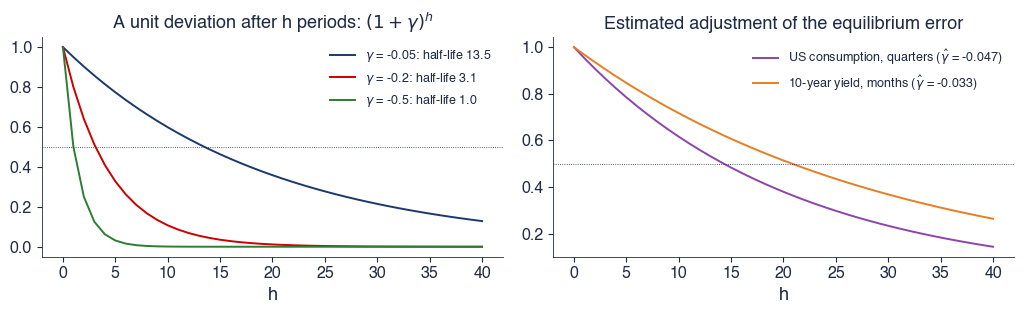

{'cons': {'beta': 1.074757958730396,
  'a': -107.57079701096234,
  'gamma': -0.04727958715825683,
  'gamma_se': 0.027041697661462995,
  'gamma_t': -1.7483956721265603,
  'delta0': 0.5366576946748534,
  'delta0_se': 0.0480389751129354,
  'const': 0.41842422242657223,
  'r2': 0.45079511484733925,
  'n': 201,
  'half': 14.311230249667052,
  'params': {'const': 0.41842422242657223,
   'e1': -0.04727958715825683,
   'dx': 0.5366576946748534,
   'dy1': -0.08079115153616848,
   'dx1': 0.08966611441343955},
  'tvalues': {'const': 7.048340944645112,
   'e1': -1.7483956721265603,
   'dx': 11.171297751736342,
   'dy1': -1.0654486130874248,
   'dx1': 1.5655607058018908}},
 'long': {'beta': 0.8561272113959144,
  'a': 2.0160192492381936,
  'gamma': -0.032739022018061385,
  'gamma_se': 0.006621786163951743,
  'gamma_t': -4.944137609922973,
  'delta0': 0.3779387881339962,
  'delta0_se': 0.020152823448642887,
  'const': 0.0005968094855127603,
  'r2': 0.3794741880009501,
  'n': 799,
  'half': 20.8234000

In [9]:
def fig_ecm(save_it=True):
    """Left: the decay (1 + gamma)^h of a unit equilibrium error for three speeds of adjustment, with half-lives.
    Right: the estimated ECMs of US consumption (quarters) and of the 10-year and 3-month yields (months)."""
    m = us_macro()
    f = read_fred(['TB3MS', 'GS10']).dropna().loc[YIELD_START:]
    cons = ecm_fit(m.c, m.y, lags=1)
    long_ = ecm_fit(f.GS10, f.TB3MS, lags=1)
    # the 3-month equation: its own change on the same equilibrium error (y - b x with y = GS10)
    e = pd.Series(ols(f.GS10, f.TB3MS)['resid'], index=f.index)
    Z = pd.DataFrame({'e1': e.shift(1), 'dy1': f.GS10.diff().shift(1), 'dx1': f.TB3MS.diff().shift(1), 'dx': f.TB3MS.diff()}).dropna()
    ms = sm.OLS(Z.dx, sm.add_constant(Z[['e1', 'dy1', 'dx1']])).fit()
    short = {'gamma': float(ms.params['e1']), 'gamma_se': float(ms.bse['e1']), 'gamma_t': float(ms.tvalues['e1'])}
    h = np.arange(0, 41)
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.3))
    for g, c in [(-0.05, st.MainBlue), (-0.2, st.IDAred), (-0.5, st.Forest)]:
        hl = half_life(1 + g)
        ax[0].plot(h, (1 + g) ** h, color=c, lw=1.4, label=f'$\\gamma$ = {g}: half-life {hl:.1f}')
    ax[0].axhline(0.5, color=st.DarkText, lw=0.6, ls=':')
    ax[0].set_title('A unit deviation after h periods: $(1+\\gamma)^h$')
    ax[0].set_xlabel('h')
    ax[0].legend(loc='upper right', fontsize=9)
    ax[1].plot(h, (1 + cons['gamma']) ** h, color=st.Purple, lw=1.4,
               label=f"US consumption, quarters ($\\hat\\gamma$ = {cons['gamma']:.3f})")
    ax[1].plot(h, (1 + long_['gamma']) ** h, color=st.Orange, lw=1.4,
               label=f"10-year yield, months ($\\hat\\gamma$ = {long_['gamma']:.3f})")
    ax[1].axhline(0.5, color=st.DarkText, lw=0.6, ls=':')
    ax[1].set_title('Estimated adjustment of the equilibrium error')
    ax[1].set_xlabel('h')
    ax[1].legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    save('tsa_ch7_ecm', save_it)
    return {'cons': cons, 'long': long_, 'short': short}


fig_ecm(save_it=False)

## 4. Johansen tests and the term-structure VECM

,trace,max-eig,rank
"US yields 1y, 5y, 10y","[54.6, 21.6, 3.1]","[33.0, 18.5, 3.1]",2
"US output, consumption, investment","[28.9, 11.4, 2.6]","[17.4, 8.9, 2.6]",0
"EUR/RON, EUR/HUF, EUR/PLN","[24.2, 7.9, 2.7]","[16.3, 5.2, 2.7]",0


beta [[0.9999999999999998, -5.878621071377144e-17], [6.286958448088155e-17, 1.0], [-1.0452781332905334, -1.0443974178773838]]
alpha [[-0.02122797751342563, 0.023605941694064422], [0.045221157218183594, -0.12163761813788743], [0.040105969057202824, -0.07669365862864595]]
t(alpha) [[-0.8208120069539196, 0.3071952746440273], [2.2093203220804414, -2.0000600813244476], [2.21515259248085, -1.425647671209647]]


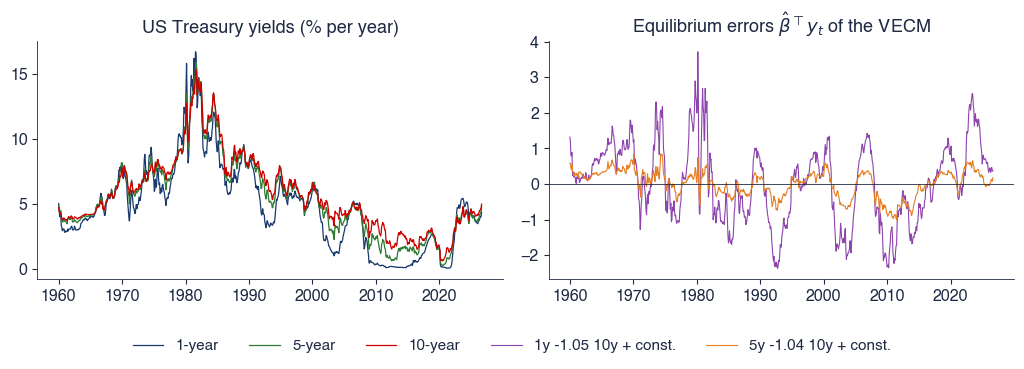

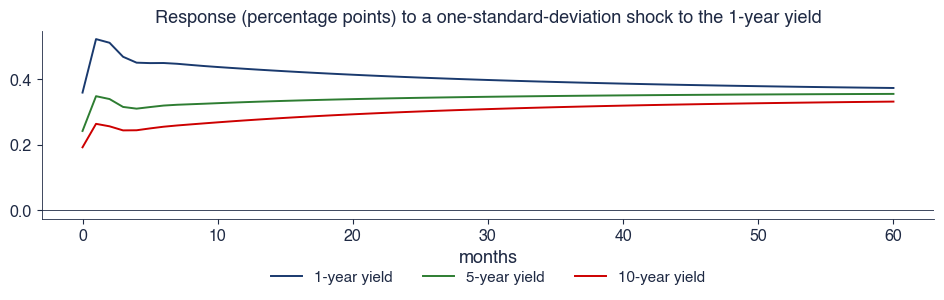

{'impact': [0.35919629474004267, 0.2417878803184677, 0.19181704853023246],
 'h12': [0.43200728217889295, 0.32995846304640913, 0.27406420873090714],
 'hH': [0.37330686567592497, 0.3552170360822182, 0.33166662377519773],
 'H': 60}

In [10]:
def johansen_systems(save_it=True):
    """Trace and maximum-eigenvalue tests (unrestricted constant) for three systems."""
    m = us_macro()
    m.index = pd.period_range('1959Q1', periods=len(m), freq='Q')
    systems = {'US yields 1y, 5y, 10y': us_yields(), 'US output, consumption, investment': m[['y', 'c', 'i']],
               'EUR/RON, EUR/HUF, EUR/PLN': cee_fx()}
    out = {k: johansen(v) for k, v in systems.items()}
    if save_it:
        rows = {}
        for k, v in out.items():
            for r in range(3):
                rows[(k, f'r <= {r}')] = {'eigenvalue': v['eig'][r], 'trace': v['trace'][r], 'trace 5%': v['trace_cv5'][r],
                                          'max-eig': v['maxeig'][r], 'max-eig 5%': v['maxeig_cv5'][r]}
        pd.DataFrame(rows).T.round(4).to_csv(os.path.join(globals().get('HERE', '.'), 'ch7_johansen.csv'))
    # the yields with the three other deterministic cases of statsmodels (no terms; linear trend)
    y = us_yields()
    out['yields_det'] = {str(d): johansen(y, det_order=d, k_ar_diff=out['US yields 1y, 5y, 10y']['k_ar_diff'])
                         for d in (-1, 0, 1)}
    return out


def vecm_rates(save_it=True):
    """The term-structure VECM: 1y, 5y and 10y yields, rank 2, constant restricted to the cointegrating relations
    (no drift in the yields); beta normalised on the 1y and 5y yields, alpha with t-statistics; the rank-1 model."""
    y = us_yields()
    k = int(max(select_order(y, maxlags=8, deterministic='co').bic, 1))
    res = VECM(y, k_ar_diff=k, coint_rank=2, deterministic='ci').fit()
    res1 = VECM(y, k_ar_diff=k, coint_rank=1, deterministic='ci').fit()
    beta = res.beta
    det = getattr(res, 'det_coef_coint', np.zeros((1, 2)))
    out = {'k_ar_diff': k, 'n': int(res.nobs), 'beta': beta.tolist(), 'const_coint': np.asarray(det).ravel().tolist(),
           'alpha': res.alpha.tolist(), 'alpha_t': res.tvalues_alpha.tolist(), 'alpha_se': res.stderr_alpha.tolist(),
           'beta1': res1.beta.ravel().tolist(), 'alpha1': res1.alpha.ravel().tolist(),
           'alpha1_t': res1.tvalues_alpha.ravel().tolist(), 'first': str(y.index[0]), 'last': str(y.index[-1]),
           'llf2': float(res.llf), 'llf1': float(res1.llf)}
    # equilibrium errors: 1y - b3 10y and 5y - b3' 10y (with the constant inside)
    sp = y.values @ beta
    out['ec_mean'] = sp.mean(axis=0).tolist()
    out['ec_sd'] = sp.std(axis=0).tolist()
    out['ec_adf'] = [adf_test(sp[:, j]) for j in range(2)]
    # speed of the equilibrium errors: the VECM implies z_t = (I + beta' alpha) z_{t-1} + ... ; eigenvalues
    B = np.asarray(beta)[:3, :]
    M = np.eye(2) + B.T @ res.alpha
    out['ec_eig'] = sorted([float(abs(v)) for v in np.linalg.eigvals(M)], reverse=True)
    out['ec_half'] = [half_life(v) for v in out['ec_eig']]
    return out


def fig_rates(save_it=True):
    """US 1y, 5y and 10y yields (FRED) and the two equilibrium errors of the rank-2 VECM."""
    y = us_yields()
    v = vecm_rates(save_it=False)
    B = np.asarray(v['beta'])[:3, :]
    z = pd.DataFrame(y.values @ B + np.asarray(v['const_coint']), index=ts_index(y), columns=['1y - b 10y', '5y - b 10y'])
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.3))
    for c, col in zip(YIELDS, [st.MainBlue, st.Forest, st.IDAred]):
        ax[0].plot(ts_index(y), y[c], color=col, lw=0.9, label={'GS1': '1-year', 'GS5': '5-year', 'GS10': '10-year'}[c])
    ax[0].set_title('US Treasury yields (% per year)')
    years_axis(ax[0], 10)
    b1, b2 = B[2, 0], B[2, 1]
    ax[1].plot(z.index, z.iloc[:, 0], color=st.Purple, lw=0.8, label=f'1y {b1:+.2f} 10y + const.')
    ax[1].plot(z.index, z.iloc[:, 1], color=st.Orange, lw=0.8, label=f'5y {b2:+.2f} 10y + const.')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('Equilibrium errors $\\hat\\beta^{\\top} y_t$ of the VECM')
    years_axis(ax[1], 10)
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_rates', save_it)
    return {'b1': float(b1), 'b2': float(b2)}


def fig_vecm_irf(H=60, save_it=True):
    """Orthogonalised impulse responses of the term-structure VECM (ordering 1y, 5y, 10y) to a shock to the
    1-year yield: the effects do not die out (a permanent shift of the level), but the spreads return."""
    y = us_yields()
    v = vecm_rates(save_it=False)
    res = VECM(y, k_ar_diff=v['k_ar_diff'], coint_rank=2, deterministic='ci').fit()
    irf = res.irf(H).orth_irfs                        # (H+1, k, k): response of i to shock j
    fig, ax = plt.subplots(figsize=(9.6, 3.3))
    for i, (c, col) in enumerate(zip(YIELDS, [st.MainBlue, st.Forest, st.IDAred])):
        ax.plot(np.arange(H + 1), irf[:, i, 0], color=col, lw=1.4,
                label={'GS1': '1-year', 'GS5': '5-year', 'GS10': '10-year'}[c] + ' yield')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_title('Response (percentage points) to a one-standard-deviation shock to the 1-year yield')
    ax.set_xlabel('months')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('tsa_ch7_vecm_irf', save_it)
    return {'impact': irf[0, :, 0].tolist(), 'h12': irf[12, :, 0].tolist(), 'hH': irf[H, :, 0].tolist(), 'H': H}


J = johansen_systems(save_it=False)
display(pd.DataFrame({k: {'trace': [round(x, 1) for x in v['trace']], 'max-eig': [round(x, 1) for x in v['maxeig']], 'rank': v['rank_trace']} for k, v in J.items() if k != 'yields_det'}).T)
VE = vecm_rates(save_it=False)
print('beta', VE['beta'])
print('alpha', VE['alpha'])
print('t(alpha)', VE['alpha_t'])
fig_rates(save_it=False)
fig_vecm_irf(save_it=False)

## 5. Forecasting: VECM against a VAR in differences

- Re-estimation at every origin; this cell takes about a minute.

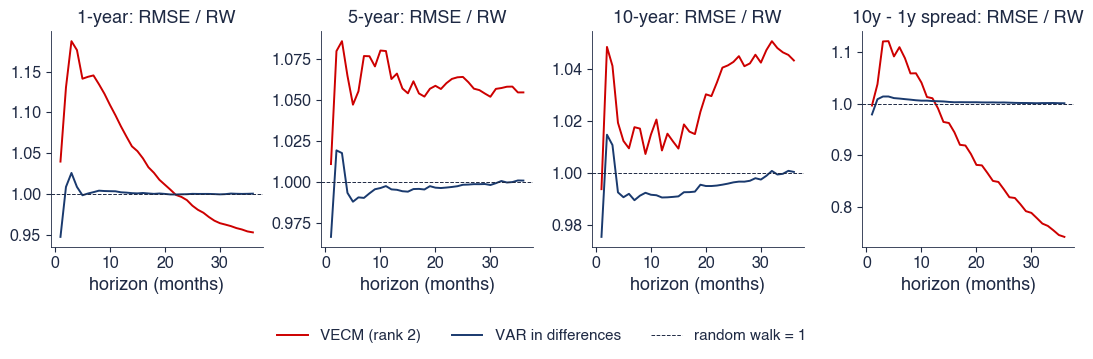

{1: [1.0397935182693405, 1.0109414711993023, 0.9936947374793156], 6: [1.1436499967919251, 1.0552570781122554, 1.0094144479139315], 12: [1.082928664396684, 1.0627018526317855, 1.0085937039917452], 24: [0.9925664777764742, 1.0637539464422174, 1.0413546681091452], 36: [0.9530424911950119, 1.0545607951174227, 1.0432526553900818]}
{1: 0.996677737588797, 6: 1.1100579642091999, 12: 1.0108458153082396, 24: 0.8482343633634147, 36: 0.7415542787984732}


In [11]:
def forecast_compare(start='1990-01', step=3, H=36, save_it=True):
    """Pseudo out-of-sample forecasts of the three yields from origins every `step` months since `start`, with
    parameters re-estimated at each origin: the rank-2 VECM (restricted constant), a VAR in differences without
    constant (same number of lagged differences) and the random walk. RMSE ratios to the random walk by horizon;
    RMSE of the forecast of the 10y-1y spread."""
    y = us_yields()
    v = vecm_rates(save_it=False)
    k = v['k_ar_diff']
    hs = np.arange(1, H + 1)
    E = {m: [] for m in ('vecm', 'dvar', 'rw')}
    origins = list(range(y.index.get_loc(pd.Period(start, 'M')), len(y) - H, step))
    for o in origins:
        tr = y.iloc[:o + 1]
        fv = VECM(tr, k_ar_diff=k, coint_rank=2, deterministic='ci').fit().predict(steps=H)
        dy = tr.diff().dropna()
        fd = VAR(dy).fit(k, trend='n').forecast(dy.values[-k:], H).cumsum(axis=0) + tr.values[-1]
        act = y.values[o + 1:o + H + 1]
        E['vecm'].append(act - fv)
        E['dvar'].append(act - fd)
        E['rw'].append(act - tr.values[-1])
    E = {m: np.array(e) for m, e in E.items()}       # (origins, H, 3)
    rmse = {m: np.sqrt((e ** 2).mean(axis=0)) for m, e in E.items()}
    spread = {m: np.sqrt(((e[:, :, 2] - e[:, :, 0]) ** 2).mean(axis=0)) for m, e in E.items()}
    fig, ax = plt.subplots(1, 4, figsize=(11.0, 3.2), sharey=False)
    for j, c in enumerate(YIELDS):
        ax[j].plot(hs, rmse['vecm'][:, j] / rmse['rw'][:, j], color=st.IDAred, lw=1.4, label='VECM (rank 2)')
        ax[j].plot(hs, rmse['dvar'][:, j] / rmse['rw'][:, j], color=st.MainBlue, lw=1.4, label='VAR in differences')
        ax[j].axhline(1, color=st.DarkText, lw=0.7, ls='--', label='random walk = 1')
        ax[j].set_title({'GS1': '1-year', 'GS5': '5-year', 'GS10': '10-year'}[c] + ': RMSE / RW')
        ax[j].set_xlabel('horizon (months)')
    ax[3].plot(hs, spread['vecm'] / spread['rw'], color=st.IDAred, lw=1.4, label='_nolegend_')
    ax[3].plot(hs, spread['dvar'] / spread['rw'], color=st.MainBlue, lw=1.4, label='_nolegend_')
    ax[3].axhline(1, color=st.DarkText, lw=0.7, ls='--', label='_nolegend_')
    ax[3].set_title('10y - 1y spread: RMSE / RW')
    ax[3].set_xlabel('horizon (months)')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_forecast', save_it)
    pick = lambda a, h: [float(x) for x in np.atleast_1d(a[h - 1])]
    return {'n_origins': len(origins), 'first_origin': str(y.index[origins[0]]), 'last_origin': str(y.index[origins[-1]]),
            'k': k, 'ratio_vecm': {h: pick(rmse['vecm'] / rmse['rw'], h) for h in (1, 6, 12, 24, 36)},
            'ratio_dvar': {h: pick(rmse['dvar'] / rmse['rw'], h) for h in (1, 6, 12, 24, 36)},
            'rmse_rw': {h: pick(rmse['rw'], h) for h in (1, 12, 36)},
            'spread_vecm': {h: float(spread['vecm'][h - 1] / spread['rw'][h - 1]) for h in (1, 6, 12, 24, 36)},
            'spread_dvar': {h: float(spread['dvar'][h - 1] / spread['rw'][h - 1]) for h in (1, 6, 12, 24, 36)}}


FC = forecast_compare(save_it=False)
print(FC['ratio_vecm'])
print(FC['spread_vecm'])

## 6. Economic examples: PPP, ROBOR and Euribor, three currencies

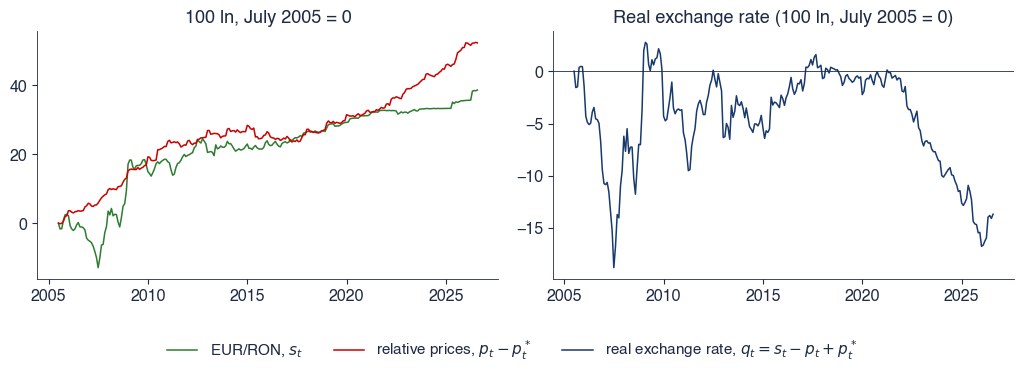

{'n': 254, 'beta': [0.8870088212537426], 'const': 148.7265317918199, 'r2': 0.859325807503777, 'dw': 0.06679272137716728, 'tau': -2.3737250169035478, 'p': 0.3373982474931688, 'crit5': -3.3603871872705398, 'crit1': -3.940251928010124, 'crit10': -3.061256130387914, 'lags': 1, 'po_zt': -2.162537928743109, 'po_p': 0.44225730072037117, 'po_crit5': -3.373852540788881, 'adf_crit5': -2.8729872043802356}


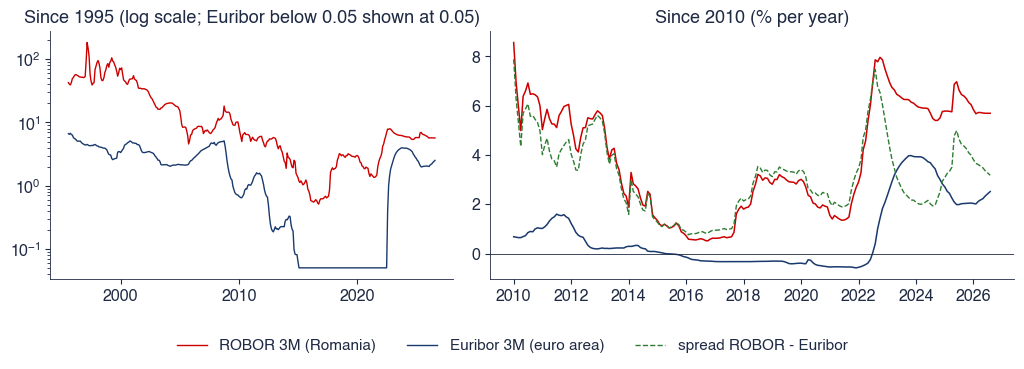

{'n': 200, 'beta': [1.19009564071485], 'const': 2.9764614543770147, 'r2': 0.520863972229604, 'dw': 0.058547455750567336, 'tau': -3.362705091935942, 'p': 0.04666493602428255, 'crit5': -3.3670063137294513, 'crit1': -3.952321293401682, 'crit10': -3.065831247948284, 'lags': 7, 'po_zt': -3.5484684986344326, 'po_p': 0.0287620073910065, 'po_crit5': -3.38420119147625, 'adf_crit5': -2.876102355}


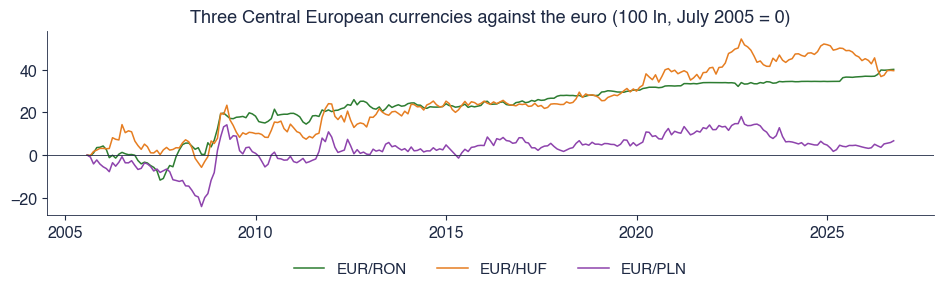

{'n': 255, 'k_ar_diff': 1, 'eig': [0.06230173504541963, 0.020397993356709727, 0.01069762259073986], 'trace': [24.20987863134962, 7.935132229051518, 2.721079143893242], 'trace_cv5': [29.7961, 15.4943, 3.8415], 'maxeig': [16.2747464022981, 5.214053085158277, 2.721079143893242], 'maxeig_cv5': [21.1314, 14.2639, 3.8415], 'rank_trace': 0, 'rank_maxeig': 0, 'first': '2005-07-31', 'last': '2026-09-30'}


In [12]:
def fig_ppp(save_it=True):
    """Purchasing power parity for EUR/RON: s_t = 100 ln(EUR/RON, monthly average of the BNR rate), relative prices
    p_t - p*_t = 100 ln(HICP Romania / HICP euro area); real exchange rate q_t = s_t - p_t + p*_t."""
    s = 100 * np.log(read_reference_rate('EUR').resample('MS').mean())
    p = 100 * np.log(read_eurostat(*HICP_RO))
    ps = 100 * np.log(read_eurostat(*HICP_EA))
    d = pd.concat([s, p, ps], axis=1, keys=['s', 'p', 'ps']).dropna()
    rel = d.p - d.ps
    q = d.s - rel
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.3))
    ax[0].plot(d.index, d.s - d.s.iloc[0], color=st.Forest, lw=1.1, label='EUR/RON, $s_t$')
    ax[0].plot(d.index, rel - rel.iloc[0], color=st.IDAred, lw=1.1, label='relative prices, $p_t - p^*_t$')
    ax[0].set_title('100 ln, July 2005 = 0')
    years_axis(ax[0], 5)
    ax[1].plot(d.index, q - q.iloc[0], color=st.MainBlue, lw=1.1, label='real exchange rate, $q_t = s_t - p_t + p^*_t$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('Real exchange rate (100 ln, July 2005 = 0)')
    years_axis(ax[1], 5)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_ppp', save_it)
    return {'n': int(len(d)), 'first': str(d.index[0])[:7], 'last': str(d.index[-1])[:7],
            'adf_q': adf_test(q, 'c'), 'adf_q_ct': adf_test(q, 'ct'), 'eg': eg_test(d.s, rel),
            'q_change': float(q.iloc[-1] - q.iloc[0]), 's_change': float(d.s.iloc[-1] - d.s.iloc[0]),
            'rel_change': float(rel.iloc[-1] - rel.iloc[0]),
            'johansen': johansen(d[['s', 'p', 'ps']])}


def fig_ro_ea_rates(save_it=True):
    """ROBOR 3M and Euribor 3M (Eurostat, monthly, % per year): the full sample and the sample since 2010."""
    d = pd.concat([read_eurostat(*ROBOR), read_eurostat(*EURIBOR)], axis=1, keys=['ro', 'ea']).dropna()
    d10 = d.loc['2010-01-01':]
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.3), gridspec_kw={'width_ratios': [1, 1.3]})
    ax[0].semilogy(d.index, d.ro, color=st.IDAred, lw=1.0, label='ROBOR 3M (Romania)')
    ax[0].semilogy(d.index, d.ea.clip(lower=0.05), color=st.MainBlue, lw=1.0, label='Euribor 3M (euro area)')
    ax[0].set_title('Since 1995 (log scale; Euribor below 0.05 shown at 0.05)')
    years_axis(ax[0], 10)
    ax[1].plot(d10.index, d10.ro, color=st.IDAred, lw=1.1, label='_nolegend_')
    ax[1].plot(d10.index, d10.ea, color=st.MainBlue, lw=1.1, label='_nolegend_')
    ax[1].plot(d10.index, d10.ro - d10.ea, color=st.Forest, lw=1.0, ls='--', label='spread ROBOR - Euribor')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('Since 2010 (% per year)')
    years_axis(ax[1], 2)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_ro_ea_rates', save_it)
    return {'first': str(d.index[0])[:7], 'last': str(d.index[-1])[:7], 'full': eg_test(d.ro, d.ea),
            'since2010': eg_test(d10.ro, d10.ea), 'adf_ro': adf_test(d10.ro), 'adf_ea': adf_test(d10.ea),
            'spread_mean10': float((d10.ro - d10.ea).mean()), 'ecm10': ecm_fit(d10.ro, d10.ea, lags=1)}


def fig_cee_fx(save_it=True):
    """EUR/RON, EUR/HUF and EUR/PLN (BNR cross rates, month-end, 100 ln, July 2005 = 0) and the Johansen test."""
    fx = cee_fx()
    z = fx - fx.iloc[0]
    fig, ax = plt.subplots(figsize=(9.6, 3.2))
    for c, col in zip(fx.columns, [st.Forest, st.Orange, st.Purple]):
        ax.plot(z.index, z[c], color=col, lw=1.1, label=c)
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_title('Three Central European currencies against the euro (100 ln, July 2005 = 0)')
    years_axis(ax, 5)
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    plt.tight_layout()
    save('tsa_ch7_cee_fx', save_it)
    j = johansen(fx)
    j12 = johansen(fx.loc['2012-01-01':], k_ar_diff=j['k_ar_diff'])
    return {'johansen': j, 'johansen12': j12, 'change': {c: float(z[c].iloc[-1]) for c in fx.columns},
            'adf': {c: adf_test(fx[c], 'c') for c in fx.columns}}


print(fig_ppp(save_it=False)['eg'])
print(fig_ro_ea_rates(save_it=False)['since2010'])
print(fig_cee_fx(save_it=False)['johansen'])

## 7. Pairs trading

- Banca Transilvania and BRD; a rolling rule on 8 BVB shares and on 6 US banks.

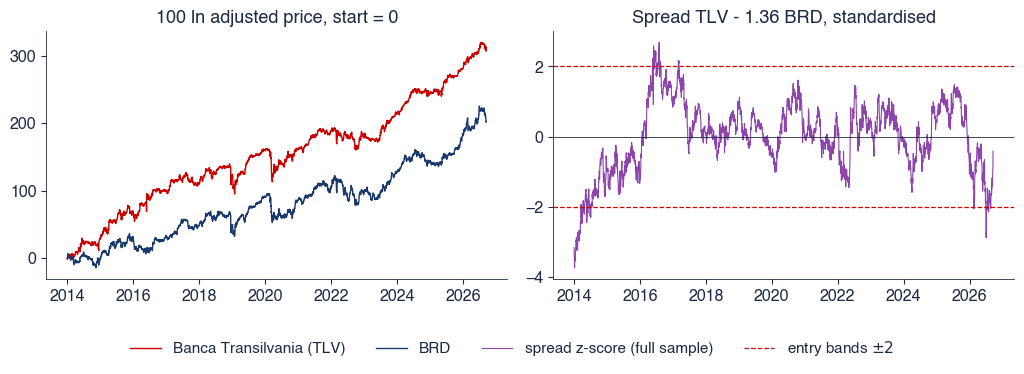

{'beta': 1.3591302611357228, 'rho': 0.989979019437891, 'half': 68.82244101115825, 'first': '2014-01-03', 'n': 3176, 'share_out': 0.05037783375314862, 'crossings': 122}


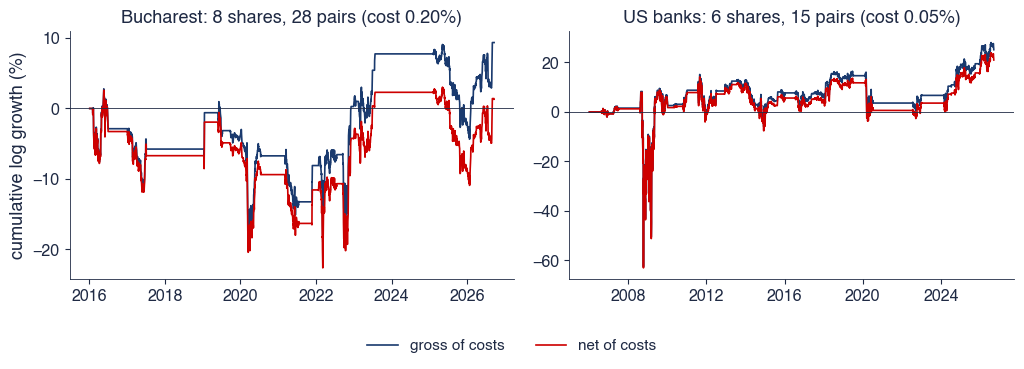

{'bvb': ({'mean': 1.1721549312892645,
   'vol': 7.621848329097841,
   'sharpe': 0.15378880301440037,
   'total': 9.35923406766902,
   'first': '2016-01-05',
   'last': '2026-09-18'},
  {'mean': 0.412394273099287,
   'vol': 7.606909142263701,
   'sharpe': 0.05421311933490041,
   'total': 1.3090157953931119,
   'first': '2016-01-05',
   'last': '2026-09-18'},
  73),
 'us': ({'mean': 2.7705269380278086,
   'vol': 17.837436228499076,
   'sharpe': 0.1553209162200847,
   'total': 25.163667558970833,
   'first': '2006-01-03',
   'last': '2026-09-18'},
  {'mean': 2.5691559702858733,
   'vol': 17.835357889527856,
   'sharpe': 0.14404846744311026,
   'total': 21.00902487015436,
   'first': '2006-01-03',
   'last': '2026-09-18'},
  80)}

In [13]:
def pairs_backtest(P, form=FORM, trade=TRADE, entry=ENTRY, cost=0.0, pmax=0.05):
    """Pairs trading with rolling windows (no look-ahead). Every `trade` days: on the previous `form` days, test each
    pair (log prices, Engle-Granger with a constant); for every pair with p < pmax, keep the OLS hedge ratio b and
    the mean and standard deviation of the spread s = ln A - a - b ln B. In the next `trade` days: open a short
    spread position (short A, long b of B) when z > entry, a long one when z < -entry; close when z crosses 0 or at
    the end of the window. Daily return of a position: pos (r_A - b r_B) / (1 + |b|), per unit of gross exposure;
    cost = cost per unit of gross exposure traded (charged when opening and when closing). The capital is split
    equally between the pairs selected in a window."""
    L = np.log(P)
    R = L.diff()
    names = list(P.columns)
    days, gross, net, n_sel, trades, wins, pair_ret = [], [], [], [], 0, 0, []
    for s0 in range(form, len(P) - 1, trade):
        fw = L.iloc[s0 - form:s0]
        sel = []
        for a, b in itertools.combinations(names, 2):
            if coint(fw[a], fw[b], trend='c', autolag='aic')[1] < pmax:
                X = np.column_stack([np.ones(form), fw[b]])
                c0, beta = np.linalg.lstsq(X, fw[a], rcond=None)[0]
                e = fw[a] - c0 - beta * fw[b]
                sel.append((a, b, c0, beta, e.mean(), e.std()))
        tw = L.iloc[s0 - 1:s0 + trade]
        idx = tw.index[1:]
        g_w, n_w = np.zeros(len(idx)), np.zeros(len(idx))
        for a, b, c0, beta, mu, sd in sel:
            z = (((tw[a] - c0 - beta * tw[b]) - mu) / sd).values
            ra, rb = R[a].reindex(tw.index).values, R[b].reindex(tw.index).values
            pos, cum = 0, 0.0
            for i in range(1, len(z)):
                r = pos * (ra[i] - beta * rb[i]) / (1 + abs(beta))
                new = pos
                if pos == 0 and z[i] > entry:
                    new = -1
                elif pos == 0 and z[i] < -entry:
                    new = 1
                elif (pos == 1 and z[i] >= 0) or (pos == -1 and z[i] <= 0) or i == len(z) - 1:
                    new = 0
                tc = cost * abs(new - pos)
                if new != 0 and pos == 0:
                    trades += 1
                    cum = 0.0
                cum += r - tc
                if new == 0 and pos != 0:
                    wins += cum > 0
                    pair_ret.append(cum)
                g_w[i - 1] += r / len(sel)
                n_w[i - 1] += (r - tc) / len(sel)
                pos = new
        days.extend(idx)
        gross.extend(g_w)
        net.extend(n_w)
        n_sel.append(len(sel))
    out = pd.DataFrame({'gross': gross, 'net': net}, index=pd.DatetimeIndex(days))
    out = out[~out.index.duplicated()]
    return out, {'windows': len(n_sel), 'pairs_tested': len(names) * (len(names) - 1) // 2,
                 'selected_mean': float(np.mean(n_sel)), 'windows_with_pairs': int(np.sum(np.array(n_sel) > 0)),
                 'trades': int(trades), 'win_rate': float(wins / max(len(pair_ret), 1)),
                 'mean_trade': float(np.mean(pair_ret)) if pair_ret else 0.0}


def perf(r, per_year=252):
    """Annualised mean (%), volatility (%), Sharpe ratio (no risk-free rate) and total log growth (%) of daily returns."""
    m, s = r.mean() * per_year, r.std() * np.sqrt(per_year)
    return {'mean': float(100 * m), 'vol': float(100 * s), 'sharpe': float(m / s) if s > 0 else 0.0,
            'total': float(100 * np.log1p(r).sum()), 'first': str(r.index[0])[:10], 'last': str(r.index[-1])[:10]}


def fig_pair(save_it=True):
    """Banca Transilvania (TLV) and BRD since 2014: log prices; the spread of the full-sample Engle-Granger
    regression as a z-score with the +-2 bands (an in-sample picture: beta, mean and standard deviation use the
    whole sample); the half-life of the spread."""
    P = 100 * np.log(stock_panel(PAIR, PAIR_START))
    r = ols(P.TLV, P.BRD)
    e = pd.Series(r['resid'], index=P.index)
    z = (e - e.mean()) / e.std()
    rho = float(np.polyfit(e.shift(1).dropna().values, e.iloc[1:].values, 1)[0])
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.3))
    ax[0].plot(P.index, P.TLV - P.TLV.iloc[0], color=st.IDAred, lw=1.0, label='Banca Transilvania (TLV)')
    ax[0].plot(P.index, P.BRD - P.BRD.iloc[0], color=st.MainBlue, lw=1.0, label='BRD')
    ax[0].set_title('100 ln adjusted price, start = 0')
    years_axis(ax[0], 2)
    ax[1].plot(z.index, z, color=st.Purple, lw=0.8, label='spread z-score (full sample)')
    for b in (-ENTRY, ENTRY):
        ax[1].axhline(b, color=st.IDAred, lw=0.9, ls='--', label='entry bands $\\pm 2$' if b > 0 else '_nolegend_')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title(f"Spread TLV - {r['b'][1]:.2f} BRD, standardised")
    years_axis(ax[1], 2)
    st.fig_legend_bottom(fig, ncol=4, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_pair', save_it)
    return {'beta': float(r['b'][1]), 'rho': rho, 'half': half_life(rho), 'first': str(P.index[0])[:10],
            'n': int(len(P)), 'share_out': float(np.mean(np.abs(z) > ENTRY)), 'crossings': int(np.sum(np.diff(np.sign(z.values)) != 0))}


def fig_pairs_backtest(save_it=True):
    """The rolling pairs-trading rule on 8 liquid BVB shares (since 2015) and on 6 US banks (since 2005): cumulative
    log growth gross and net of costs (0.20% and 0.05% per unit of gross exposure traded); the in-sample illusion of
    trading TLV/BRD with full-sample parameters."""
    bvb = stock_panel(BVB, '2015-01-01')
    us = stock_panel(US_BANKS, '2005-01-01', calendar='sp500')
    rb, ib = pairs_backtest(bvb, cost=COST_BVB)
    ru, iu = pairs_backtest(us, cost=COST_US)
    fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.3))
    for a, r, t, cst in [(ax[0], rb, 'Bucharest: 8 shares, 28 pairs', COST_BVB), (ax[1], ru, 'US banks: 6 shares, 15 pairs', COST_US)]:
        a.plot(r.index, 100 * np.log1p(r.gross).cumsum(), color=st.MainBlue, lw=1.2, label='gross of costs')
        a.plot(r.index, 100 * np.log1p(r.net).cumsum(), color=st.IDAred, lw=1.2, label='net of costs')
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(t + f' (cost {100 * cst:.2f}%)')
        years_axis(a, 2 if a is ax[0] else 4)
    ax[0].set_ylabel('cumulative log growth (%)')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch7_pairs_backtest', save_it)
    out = {'bvb': {'gross': perf(rb.gross), 'net': perf(rb.net), **ib, 'cost': COST_BVB},
           'us': {'gross': perf(ru.gross), 'net': perf(ru.net), **iu, 'cost': COST_US}}
    # break-even cost: the cost that sets the net mean return to zero (linear in the cost)
    for k, r, info, c in [('bvb', rb, ib, COST_BVB), ('us', ru, iu, COST_US)]:
        drag = (r.gross.mean() - r.net.mean()) / c if c > 0 else np.nan
        out[k]['breakeven'] = float(r.gross.mean() / drag) if drag > 0 else float('nan')
    # the in-sample illusion on TLV/BRD: full-sample beta, mean and sd, the same entry and exit rules
    P = stock_panel(PAIR, PAIR_START)
    L = np.log(P)
    X = np.column_stack([np.ones(len(L)), L.BRD])
    c0, beta = np.linalg.lstsq(X, L.TLV, rcond=None)[0]
    e = L.TLV - c0 - beta * L.BRD
    z = ((e - e.mean()) / e.std()).values
    R = L.diff().values
    pos, rets = 0, []
    for i in range(1, len(z)):
        rets.append(pos * (R[i, 0] - beta * R[i, 1]) / (1 + abs(beta)))
        new = pos
        if pos == 0 and z[i] > ENTRY:
            new = -1
        elif pos == 0 and z[i] < -ENTRY:
            new = 1
        elif (pos == 1 and z[i] >= 0) or (pos == -1 and z[i] <= 0):
            new = 0
        if new != pos:
            rets[-1] -= COST_BVB * abs(new - pos)
        pos = new
    ins = pd.Series(rets, index=P.index[1:])
    out['insample'] = perf(ins)
    out['tlvbrd_rolling'] = pairs_backtest(P, cost=COST_BVB)[1]
    return out


print(fig_pair(save_it=False))
PB = fig_pairs_backtest(save_it=False)
{k: (PB[k]['gross'], PB[k]['net'], PB[k]['trades']) for k in ('bvb', 'us')}

## Exercises

1. Test PPP for EUR/PLN with Polish and euro-area HICP (`prc_hicp_minr`, key `M.I15.TOTAL.PL`).
2. Re-run the Johansen test for the yields with 4 and 8 lagged differences: does the rank change?
3. Change the entry threshold of `pairs_backtest` to 1.5 and 2.5 and the cost to 0.10%: how do the net results change?